<a href="https://colab.research.google.com/github/JaredOzarzak/biomechanics-analysis-pipeline/blob/main/Force_Plate_Signal_Processing_Test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt
from scipy.integrate import trapezoid

In [2]:
# Set seed so results are repeatable
np.random.seed(42)

# Create time vector
time = np.linspace(0, 1.2, 500)

# Create a clean force curve, similar to a landing or force plate contact event
grf_clean = 900 * np.exp(-((time - 0.55) ** 2) / 0.015)

# Add random sensor noise to simulate raw force plate output
noise = np.random.normal(0, 45, size=time.shape)
grf_raw = grf_clean + noise

# Store raw data in a DataFrame
df = pd.DataFrame({
    "time_s": time,
    "grf_raw_N": grf_raw
})

df.head()

,time_s,grf_raw_N
0,0.000000,22.352138
1,0.002405,-6.221892
2,0.004810,29.145986
3,0.007214,68.536346
4,0.009619,-10.536899


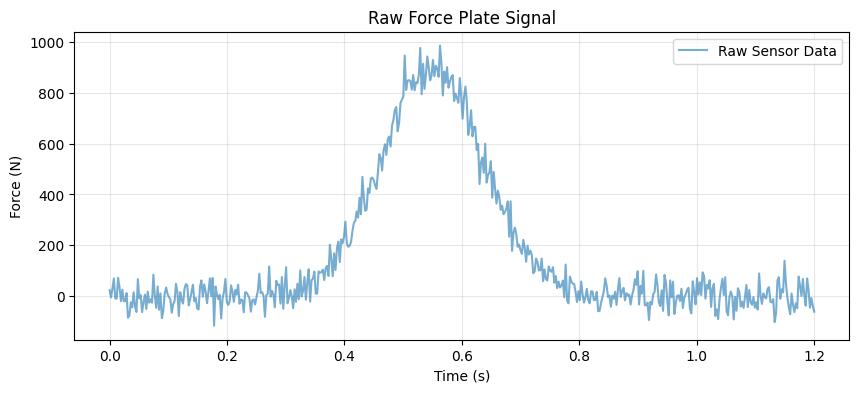

In [3]:
plt.figure(figsize=(10, 4))
plt.plot(df["time_s"], df["grf_raw_N"], label="Raw Sensor Data", alpha=0.6)

plt.title("Raw Force Plate Signal")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

In [5]:
def apply_butterworth(data, cutoff=15, fs=416, order=4):
    """
    Applies a zero-phase 4th-order Butterworth low-pass filter.
    Zero-phase filtering helps keep the timing of the signal aligned.
    """
    nyquist = 0.5 * fs
    normalized_cutoff = cutoff / nyquist

    b, a = butter(order, normalized_cutoff, btype="low", analog=False)
    filtered_data = filtfilt(b, a, data)

    return filtered_data


# Apply filter and update dataframe
df["grf_filtered_N"] = apply_butterworth(df["grf_raw_N"])

print("Filter applied successfully using a zero-phase 4th-order Butterworth filter.")

Filter applied successfully using a zero-phase 4th-order Butterworth filter.


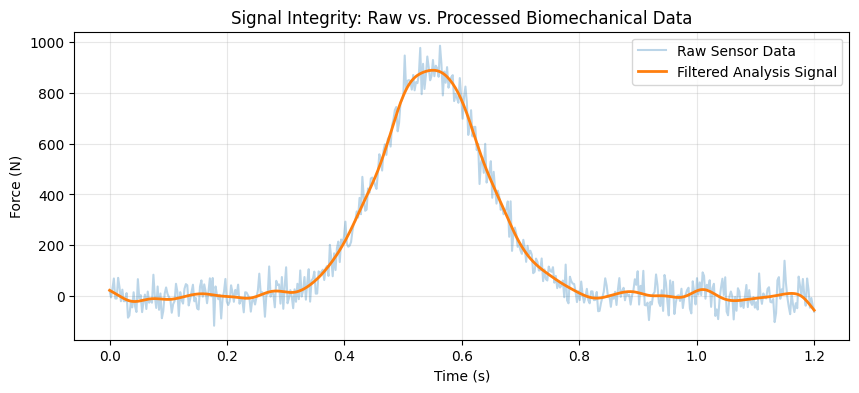

In [6]:
plt.figure(figsize=(10, 4))

plt.plot(
    df["time_s"],
    df["grf_raw_N"],
    alpha=0.3,
    label="Raw Sensor Data"
)

plt.plot(
    df["time_s"],
    df["grf_filtered_N"],
    linewidth=2,
    label="Filtered Analysis Signal"
)

plt.title("Signal Integrity: Raw vs. Processed Biomechanical Data")
plt.xlabel("Time (s)")
plt.ylabel("Force (N)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

In [7]:
# Peak force
peak_force = np.max(df["grf_filtered_N"])

# Loading rate, also known as rate of force development
loading_rate = np.max(
    np.gradient(df["grf_filtered_N"], df["time_s"])
)

# Impulse, area under the force-time curve
impulse = trapezoid(df["grf_filtered_N"], df["time_s"])

print("Extracted KPIs")
print("----------------")
print(f"Peak Force: {peak_force:.1f} N")
print(f"Loading Rate: {loading_rate / 1000:.1f} kN/s")
print(f"Impulse: {impulse:.1f} N·s")

Extracted KPIs
----------------
Peak Force: 890.1 N
Loading Rate: 7.4 kN/s
Impulse: 195.3 N·s


In [8]:
kpi_summary = pd.DataFrame({
    "Metric": [
        "Peak Force",
        "Loading Rate",
        "Impulse"
    ],
    "Value": [
        peak_force,
        loading_rate / 1000,
        impulse
    ],
    "Unit": [
        "N",
        "kN/s",
        "N·s"
    ]
})

kpi_summary

,Metric,Value,Unit
0,Peak Force,890.077822,N
1,Loading Rate,7.435847,kN/s
2,Impulse,195.315785,N·s


In [12]:
df.to_csv("force_plate_signal_processed.csv", index=False)
kpi_summary.to_csv("force_plate_kpi_summary.csv", index=False)

print("Files saved:")
print("- force_plate_signal_processed.csv")
print("- force_plate_kpi_summary.csv")

Files saved:
- force_plate_signal_processed.csv
- force_plate_kpi_summary.csv


In [13]:
from google.colab import files

files.download("force_plate_signal_processed.csv")
files.download("force_plate_kpi_summary.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
print("""
Project Summary:
This notebook demonstrates a force plate signal processing workflow for test engineering.
It creates a simulated raw force signal, applies a zero-phase Butterworth filter, and extracts
key performance metrics including peak force, loading rate, and impulse.

The goal is to show how raw sensor data can be checked, cleaned, and converted into usable
outputs for testing, troubleshooting, and performance analysis.
""")


Project Summary:
This notebook demonstrates a force plate signal processing workflow for test engineering.
It creates a simulated raw force signal, applies a zero-phase Butterworth filter, and extracts
key performance metrics including peak force, loading rate, and impulse.

The goal is to show how raw sensor data can be checked, cleaned, and converted into usable
outputs for testing, troubleshooting, and performance analysis.

